# 可选实验 - 神经元与层
在本实验中，我们将探索神经元/单元和层的内部工作原理。特别是，本实验将与你在课程1中掌握的模型进行类比，即回归/线性模型和逻辑回归模型。本实验将介绍Tensorflow并演示这些模型在该框架中的实现方式。
<figure>
   <img src="./images/C2_W1_NeuronsAndLayers.png"  style="width:540px;height:200px;" >
</figure>


## 包
**Tensorflow和Keras**  
Tensorflow是Google开发的机器学习包。2019年，Google将Keras集成到Tensorflow中并发布了Tensorflow 2.0。Keras是由François Chollet独立开发的框架，为Tensorflow创建了一个简单的、以层为中心的接口。本课程将使用Keras接口。

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError, BinaryCrossentropy
from tensorflow.keras.activations import sigmoid
from lab_utils_common import dlc
from lab_neurons_utils import plt_prob_1d, sigmoidnp, plt_linear, plt_logistic
plt.style.use('./deeplearning.mplstyle')
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

## 无激活函数的神经元 - 回归/线性模型

### 数据集
我们将使用课程1中的一个例子，关于房价的线性回归。

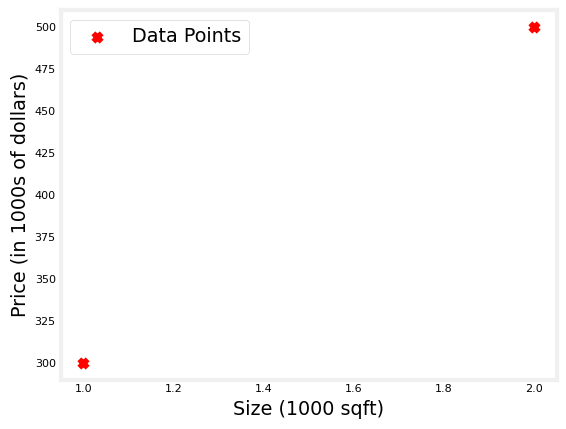

In [21]:
X_train = np.array([[1.0], [2.0]], dtype=np.float32)           #（面积，单位：千平方英尺）
Y_train = np.array([[300.0], [500.0]], dtype=np.float32)       #（价格，单位：千美元）

fig, ax = plt.subplots(1,1)
ax.scatter(X_train, Y_train, marker='x', c='r', label="Data Points")
ax.legend( fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')
plt.show()

### 回归/线性模型 
没有激活函数的神经元实现的功能与课程1中的线性回归相同：
$$ f_{\mathbf{w},b}(x^{(i)}) = \mathbf{w}\cdot x^{(i)} + b \tag{1}$$



我们可以定义一个包含一个神经元或单元的层，并将其与熟悉的线性回归函数进行比较。

In [22]:
linear_layer = tf.keras.layers.Dense(units=1, activation = 'linear', )

让我们检查权重。

In [23]:
linear_layer.get_weights()

[]

没有权重，因为权重尚未实例化。让我们在`X_train`中的一个样本上尝试模型。这将触发权重的实例化。注意，层的输入必须是2维的，所以我们将对其进行重塑。

In [24]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

tf.Tensor([[-0.19]], shape=(1, 1), dtype=float32)


结果是一个形状为(1,1)的张量（数组的另一个名称），即一个元素。   
现在让我们看看权重和偏置。这些权重被随机初始化为小数字，偏置默认初始化为零。

In [25]:
w, b= linear_layer.get_weights()
print(f"w = {w}, b={b}")

w = [[-0.19]], b=[0.]


具有单个输入特征的线性回归模型(1)将具有单个权重和偏置。这与我们上面的`linear_layer`的维度相匹配。   

权重被初始化为随机值，所以让我们将它们设置为一些已知值。

In [26]:
set_w = np.array([[200]])
set_b = np.array([100])

# set_weights接受一个numpy数组列表
linear_layer.set_weights([set_w, set_b])
print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


让我们将公式(1)与层输出进行比较。

In [27]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)
alin = np.dot(set_w,X_train[0].reshape(1,1)) + set_b
print(alin)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


它们产生了相同的值！
现在，我们可以使用线性层对训练数据进行预测。

In [28]:
prediction_tf = linear_layer(X_train)
prediction_np = np.dot( X_train, set_w) + set_b

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21315 (\N{CJK UNIFIED IDEOGRAPH-5343}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32654 (\N{CJK UNIFIED IDEOGRAPH-7F8E}) m

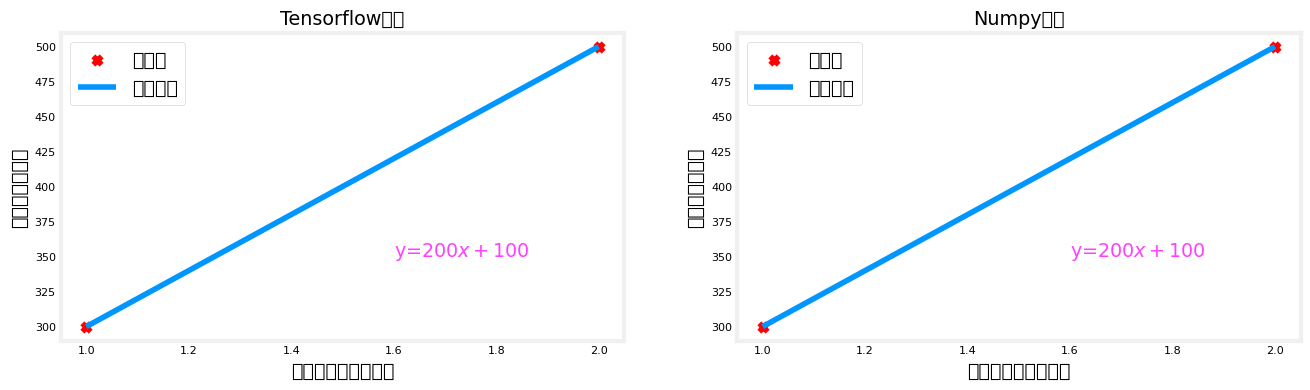

In [29]:
plt_linear(X_train, Y_train, prediction_tf, prediction_np)

## 带有Sigmoid激活函数的神经元
带有sigmoid激活函数的神经元/单元实现的功能与课程1中的逻辑回归相同：
$$ f_{\mathbf{w},b}(x^{(i)}) = g(\mathbf{w}x^{(i)} + b) \tag{2}$$
其中 $$g(x) = sigmoid(x)$$ 

让我们将$w$和$b$设置为一些已知值并检查模型。


### 数据集
我们将使用课程1中的一个例子，逻辑回归。

In [30]:
X_train = np.array([0., 1, 2, 3, 4, 5], dtype=np.float32).reshape(-1,1)  # 二维矩阵
Y_train = np.array([0,  0, 0, 1, 1, 1], dtype=np.float32).reshape(-1,1)  # 二维矩阵

In [31]:
pos = Y_train == 1
neg = Y_train == 0
X_train[pos]

array([3., 4., 5.], dtype=float32)

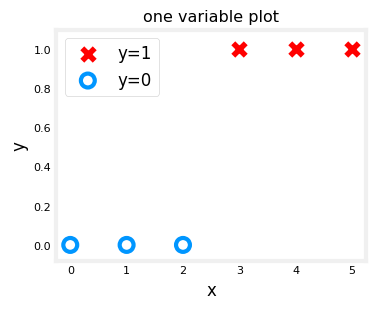

In [32]:
pos = Y_train == 1
neg = Y_train == 0

fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(X_train[pos], Y_train[pos], marker='x', s=80, c = 'red', label="y=1")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, label="y=0", facecolors='none', 
              edgecolors=dlc["dlblue"],lw=3)

ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_title('one variable plot')
ax.legend(fontsize=12)
plt.show()

### 逻辑神经元
我们可以通过添加sigmoid激活函数来实现一个'逻辑神经元'。神经元的功能由上面的公式(2)描述。   
本节将创建一个包含逻辑层的Tensorflow模型，以演示创建模型的另一种方法。Tensorflow最常用于创建多层模型。[Sequential](https://keras.io/guides/sequential_model/)模型是构建这些模型的便捷方式。

In [33]:
model = Sequential(
    [
        tf.keras.layers.Dense(1, input_dim=1,  activation = 'sigmoid', name='L1')
    ]
)

/home/dev/gpu/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


`model.summary()`显示模型中的层和参数数量。这个模型只有一层，该层只有一个单元。该单元有两个参数，$w$和$b$。

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
logistic_layer = model.get_layer('L1')
w,b = logistic_layer.get_weights()
print(w,b)
print(w.shape,b.shape)

[[-1.72]] [0.]
(1, 1) (1,)


让我们将权重和偏置设置为一些已知值。

In [36]:
set_w = np.array([[2]])
set_b = np.array([-4.5])
# set_weights接受一个numpy数组列表
logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())

[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


让我们将公式(2)与层输出进行比较。

In [37]:
a1 = model.predict(X_train[0].reshape(1,1))
print(a1)
alog = sigmoidnp(np.dot(set_w,X_train[0].reshape(1,1)) + set_b)
print(alog)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.01]]
[[0.01]]


它们产生了相同的值！
现在，我们可以使用逻辑层和NumPy模型对训练数据进行预测。

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━

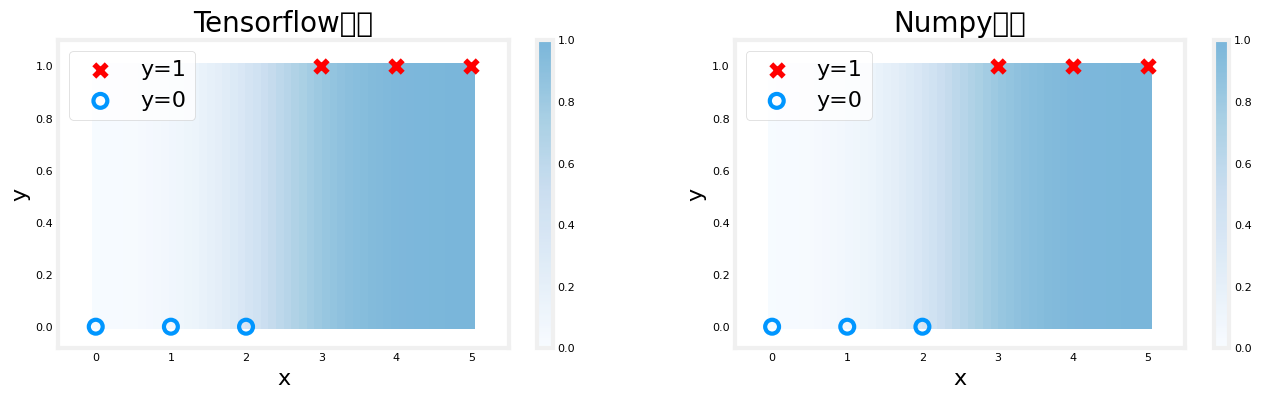

In [38]:
plt_logistic(X_train, Y_train, model, set_w, set_b, pos, neg)

上面的阴影反映了sigmoid的输出，其值从0到1变化。

# 恭喜！
你构建了一个非常简单的神经网络，并探索了神经元与课程1中线性回归和逻辑回归的相似之处。